# Regressão Linear - SOJA3 (Dataset Dummy)
## Análise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de regressão linear para prever o preço de fechamento futuro das ações SOJA3 em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset com variáveis dummy de período (period_1, period_2) via One-Hot Encoding.

### Importação das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
import os

# Configuração para salvar gráficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carrega o dataset tratado com variáveis dummy
df = pd.read_csv('../../../../datasets/datasets_dummy/regressao/SOJA3_tratado.csv', index_col=0, parse_dates=True)

print("="*60)
print("DATASET SOJA3 - REGRESSÃO LINEAR (DUMMY)")
print("="*60)
print(f"\nPrimeiras 5 linhas do DataFrame:")
print(df.head())

print(f"\nInformações gerais do DataFrame:")
print(df.info())

print(f"\nColunas disponíveis:")
print(df.columns.tolist())

print(f"\nEstatísticas descritivas:")
print(df.describe())

DATASET SOJA3 - REGRESSÃO LINEAR (DUMMY)

Primeiras 5 linhas do DataFrame:
                Close       High        Low       Open   Volume  Close_3d_fut  \
Date                                                                            
2021-04-30  14.651416  16.170820  13.566125  13.656566  7654100     14.126859   
2021-05-03  14.506711  15.555825  14.009285  15.555825  3088000     13.810316   
2021-05-04  14.380093  15.031268  14.199211  14.660459  1238100     13.837448   
2021-05-05  14.126859  14.560975  14.117814  14.551931   832000     13.665610   
2021-05-06  13.810316  14.334873  13.756051  14.334873   637000     13.566125   

            Close_7d_fut  Close_15d_fut  Close_30d_fut  period_1  period_2  
Date                                                                        
2021-04-30     13.566125      14.434359      13.837448         0         0  
2021-05-03     13.611345      14.660459      13.918846         0         0  
2021-05-04     14.633327      14.488623      13.9

### Preparação dos dados para modelagem

In [2]:
# Identificar colunas dummy (period_1, period_2)
dummy_cols = [col for col in df.columns if col.startswith('period_')]
print(f"Colunas dummy encontradas: {dummy_cols}")

# Definir variáveis independentes (features base + dummy)
base_features = ['Close', 'Low', 'High', 'Open']
X = df[base_features + dummy_cols]

# Definir targets (variáveis dependentes) - janelas temporais
targets = {
    '3d': df['Close_3d_fut'],
    '7d': df['Close_7d_fut'], 
    '15d': df['Close_15d_fut'],
    '30d': df['Close_30d_fut']
}

print("\nVariáveis independentes (X):")
print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")

print("\nTargets (janelas temporais):")
for name, target in targets.items():
    print(f"  - {name}: {target.name}")

Colunas dummy encontradas: ['period_1', 'period_2']

Variáveis independentes (X):
['Close', 'Low', 'High', 'Open', 'period_1', 'period_2']

Shape de X: (887, 6)

Targets (janelas temporais):
  - 3d: Close_3d_fut
  - 7d: Close_7d_fut
  - 15d: Close_15d_fut
  - 30d: Close_30d_fut


### Treinamento dos Modelos de Regressão Linear

In [3]:
print("MODELOS DE REGRESSÃO LINEAR - SOJA3 (DUMMY)")
print("="*60)

# Dicionário para armazenar modelos treinados e métricas
models = {}

# Treinar modelo para cada janela temporal
for period, y in targets.items():
    # Divisão treino-teste (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Armazenar modelo e métricas
    models[period] = {
        'model': model,
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred
    }
    
    print(f"\nMODELO {period.upper()} - Predição Close {period} futuro:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Intercepto: {model.intercept_:.4f}")
    print(f"  Coeficientes:")
    for i, feature in enumerate(X.columns):
        print(f"    {feature}: {model.coef_[i]:.4f}")

print(f"\n" + "="*60)
print(f"✓ 4 modelos treinados com sucesso!")
print("="*60)

MODELOS DE REGRESSÃO LINEAR - SOJA3 (DUMMY)

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9454
  MAE: 0.3453
  RMSE: 0.4328
  Intercepto: -0.5065
  Coeficientes:
    Close: 0.7059
    Low: 0.0131
    High: 0.3975
    Open: -0.1498
    period_1: 0.8389
    period_2: 0.8517

MODELO 7D - Predição Close 7d futuro:
  R²: 0.8584
  MAE: 0.5554
  RMSE: 0.7010
  Intercepto: 0.1020
  Coeficientes:
    Close: 0.8248
    Low: -0.1027
    High: 0.2199
    Open: -0.0090
    period_1: 0.6783
    period_2: 0.6725

MODELO 15D - Predição Close 15d futuro:
  R²: 0.7314
  MAE: 0.7195
  RMSE: 0.9313
  Intercepto: 1.3900
  Coeficientes:
    Close: 0.8523
    Low: -0.3357
    High: 0.3940
    Open: -0.0477
    period_1: 0.1576
    period_2: 0.1277

MODELO 30D - Predição Close 30d futuro:
  R²: 0.5338
  MAE: 1.0000
  RMSE: 1.3035
  Intercepto: 2.3444
  Coeficientes:
    Close: 0.7382
    Low: -0.7233
    High: 0.6590
    Open: 0.0440
    period_1: 0.8903
    period_2: 0.7899

✓ 4 modelos treinados com sucess

### Tabela Resumo das Métricas

In [4]:
# Criar DataFrame com resumo das métricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'R²': [models['3d']['r2'], models['7d']['r2'], models['15d']['r2'], models['30d']['r2']],
    'MAE': [models['3d']['mae'], models['7d']['mae'], models['15d']['mae'], models['30d']['mae']],
    'RMSE': [models['3d']['rmse'], models['7d']['rmse'], models['15d']['rmse'], models['30d']['rmse']]
})

print("\nRESUMO DAS MÉTRICAS - SOJA3 (DUMMY)")
print("="*60)
print(metrics_summary.to_string(index=False))

# Salvar métricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_soja3_dummy.csv', index=False)
print(f"\n✓ Métricas salvas em metricas_soja3_dummy.csv")


RESUMO DAS MÉTRICAS - SOJA3 (DUMMY)
Horizonte       R²      MAE     RMSE
   3 dias 0.945421 0.345253 0.432757
   7 dias 0.858382 0.555392 0.701018
  15 dias 0.731436 0.719466 0.931300
  30 dias 0.533777 1.000023 1.303497

✓ Métricas salvas em metricas_soja3_dummy.csv


---
# Análises Gráficas

### Gráficos de Série Temporal - Real vs Predito

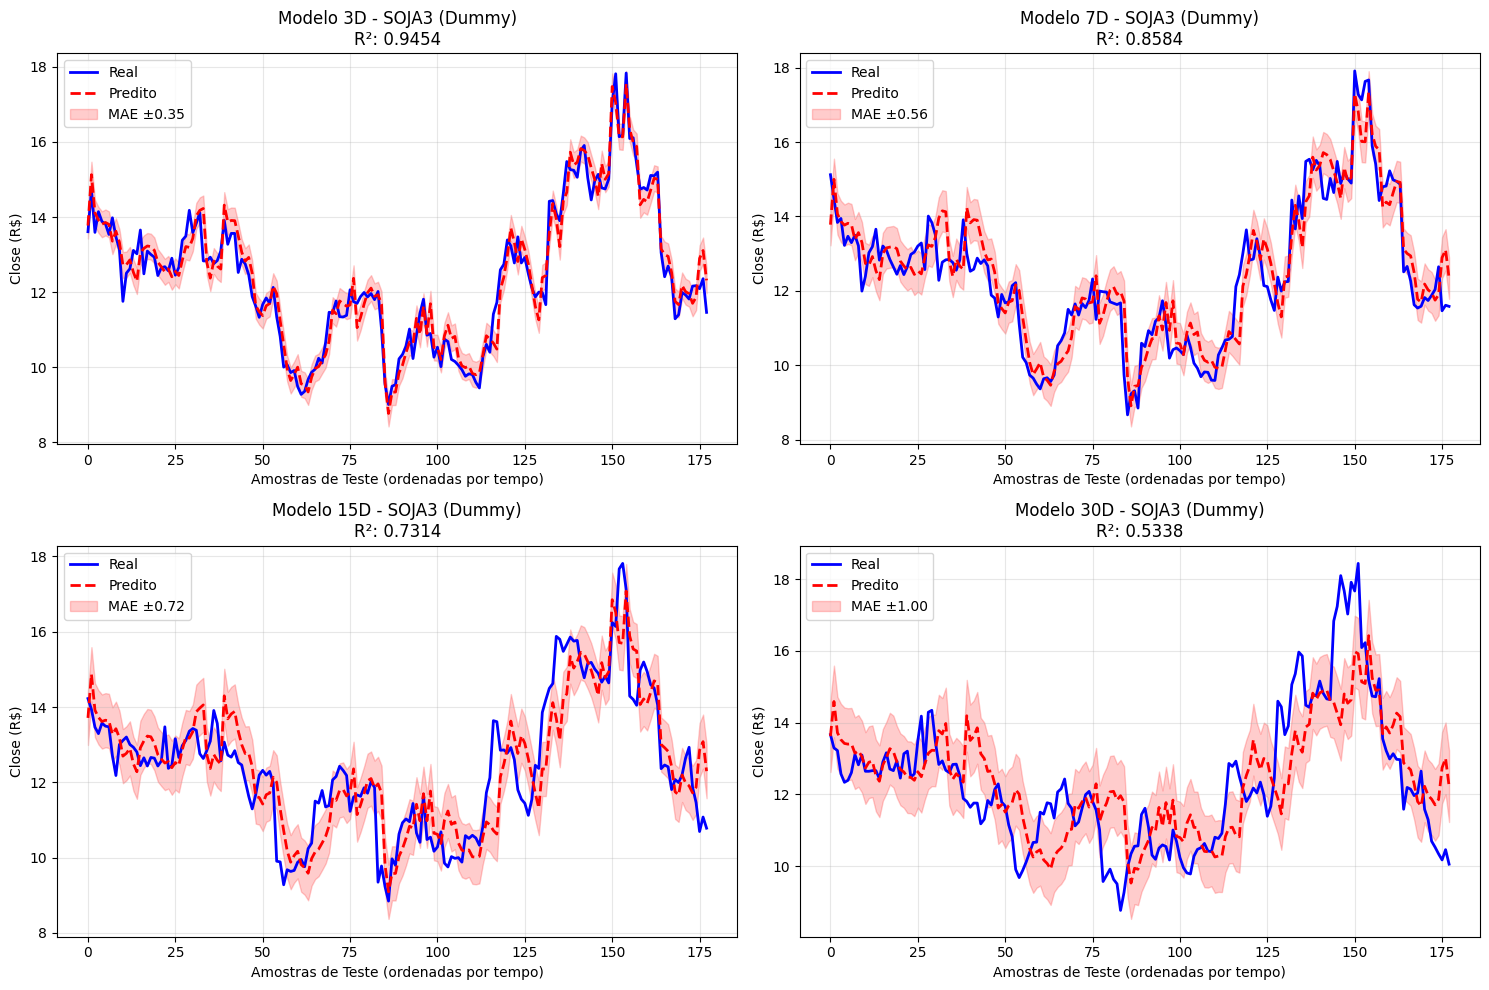

✓ Gráfico de série temporal salvo


In [5]:
# Gráficos de série temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    mae = model_data['mae']
    
    # Ordenar por índice para visualização temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    
    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)
    
    # Adicionar túnel do MAE
    ax.fill_between(range(len(y_pred_sorted)), 
                    y_pred_sorted - mae, 
                    y_pred_sorted + mae, 
                    alpha=0.2, color='red', label=f'MAE ±{mae:.2f}')
    
    ax.set_title(f'Modelo {period.upper()} - SOJA3 (Dummy)\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}serie_temporal_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de série temporal salvo")

### Gráficos de Resíduos

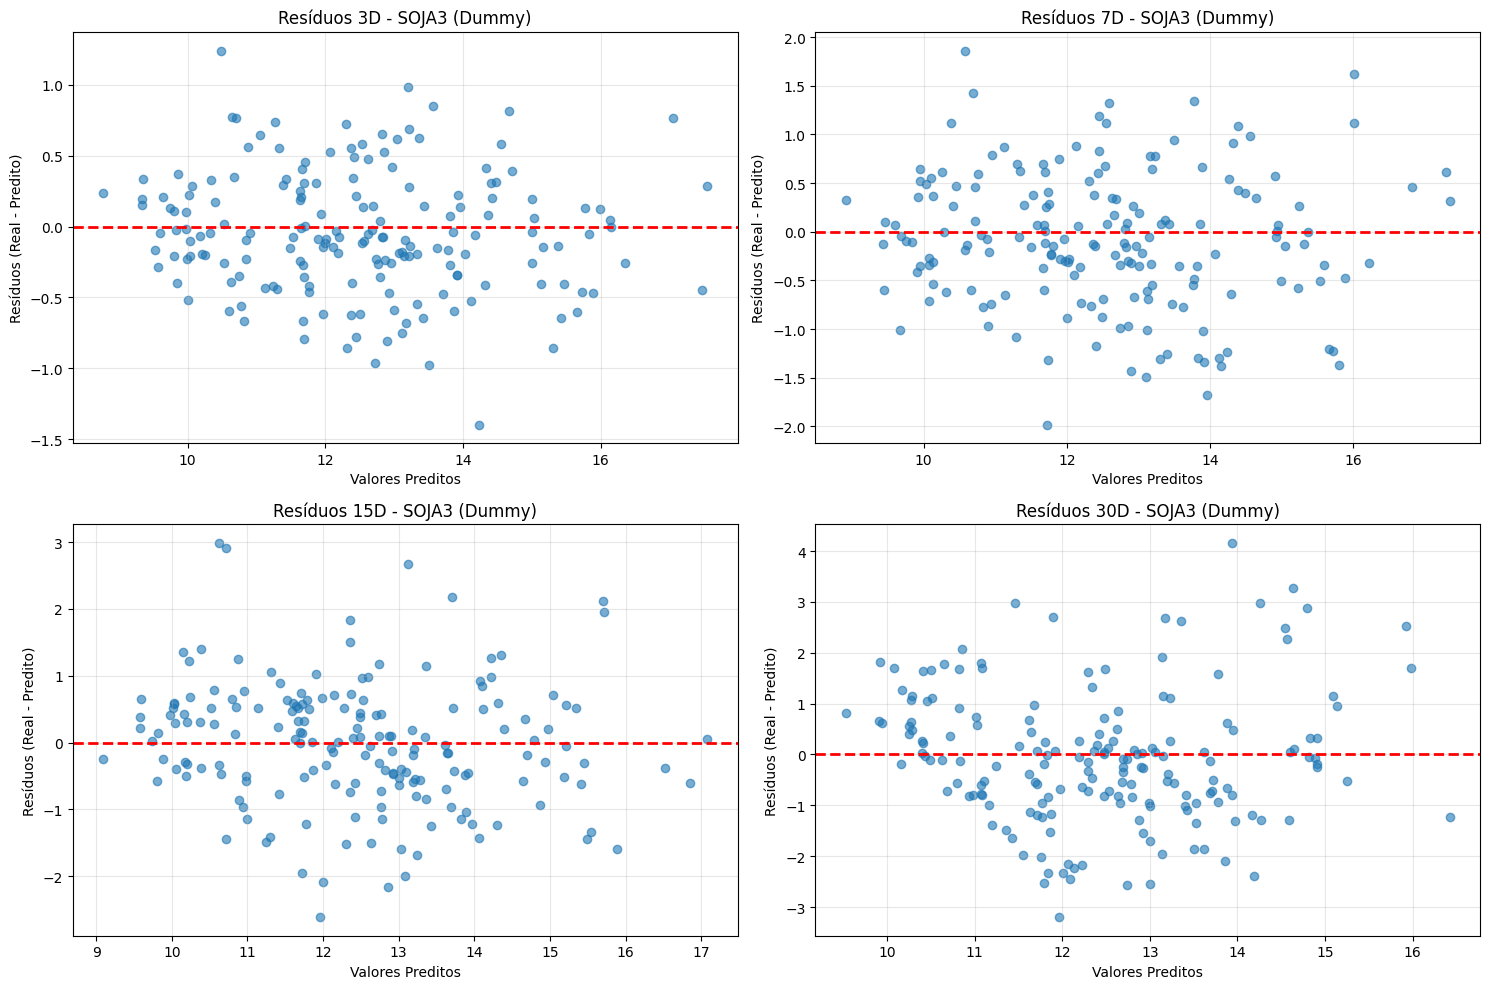

✓ Gráfico de resíduos salvo


In [6]:
# Gráficos de resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos {period.upper()} - SOJA3 (Dummy)')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Resíduos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de resíduos salvo")

### Gráficos Real vs Predito

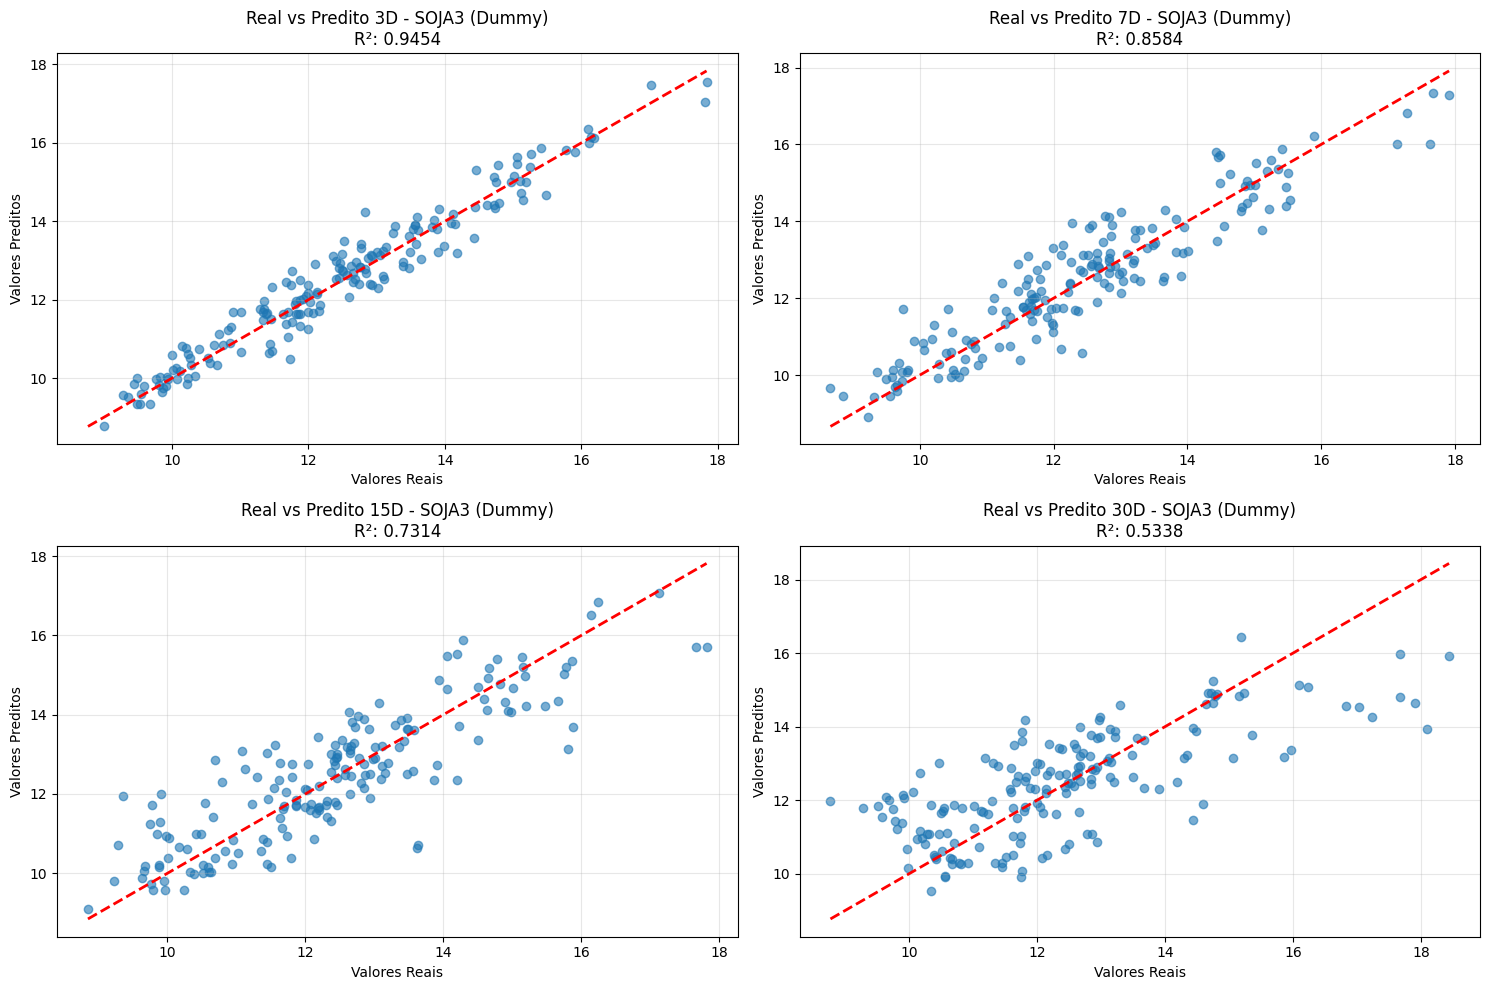

✓ Gráfico real vs predito salvo


In [7]:
# Gráficos Real vs Predito
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_title(f'Real vs Predito {period.upper()} - SOJA3 (Dummy)\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}real_vs_predito_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico real vs predito salvo")

### Comparação das Métricas (R² e MAE)

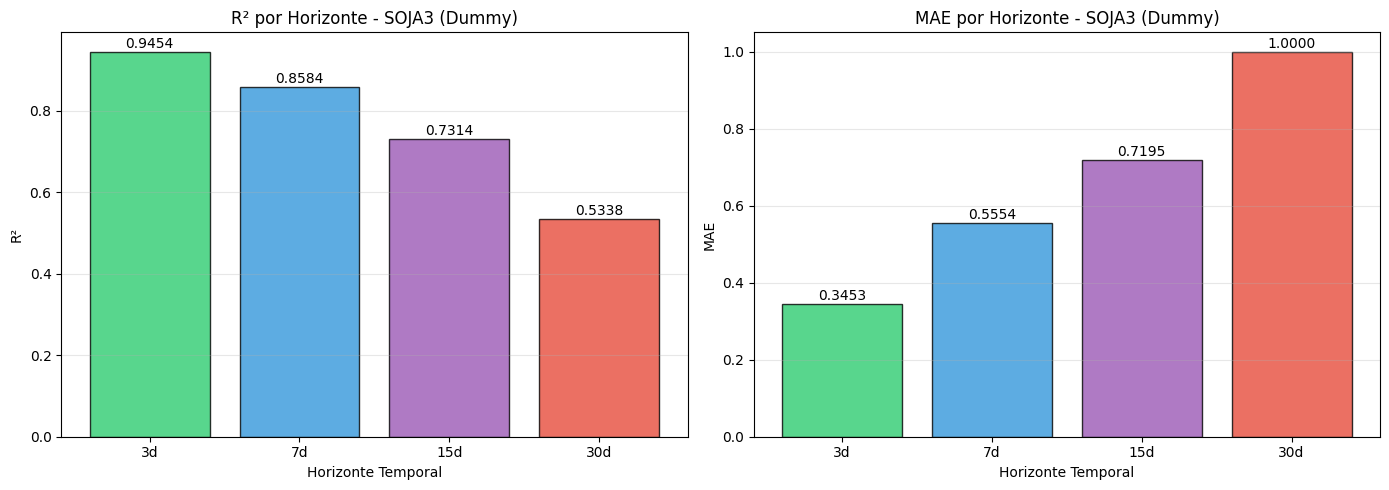

✓ Gráfico de comparação de métricas salvo


In [8]:
# Comparação das métricas entre horizontes
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico R²
x = np.arange(len(periods))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

ax1.bar(x, r2_values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Horizonte Temporal')
ax1.set_ylabel('R²')
ax1.set_title('R² por Horizonte - SOJA3 (Dummy)')
ax1.set_xticks(x)
ax1.set_xticklabels(periods)
ax1.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(r2_values):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Gráfico MAE
ax2.bar(x, mae_values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Horizonte Temporal')
ax2.set_ylabel('MAE')
ax2.set_title('MAE por Horizonte - SOJA3 (Dummy)')
ax2.set_xticks(x)
ax2.set_xticklabels(periods)
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(mae_values):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de comparação de métricas salvo")

### Histogramas dos Resíduos

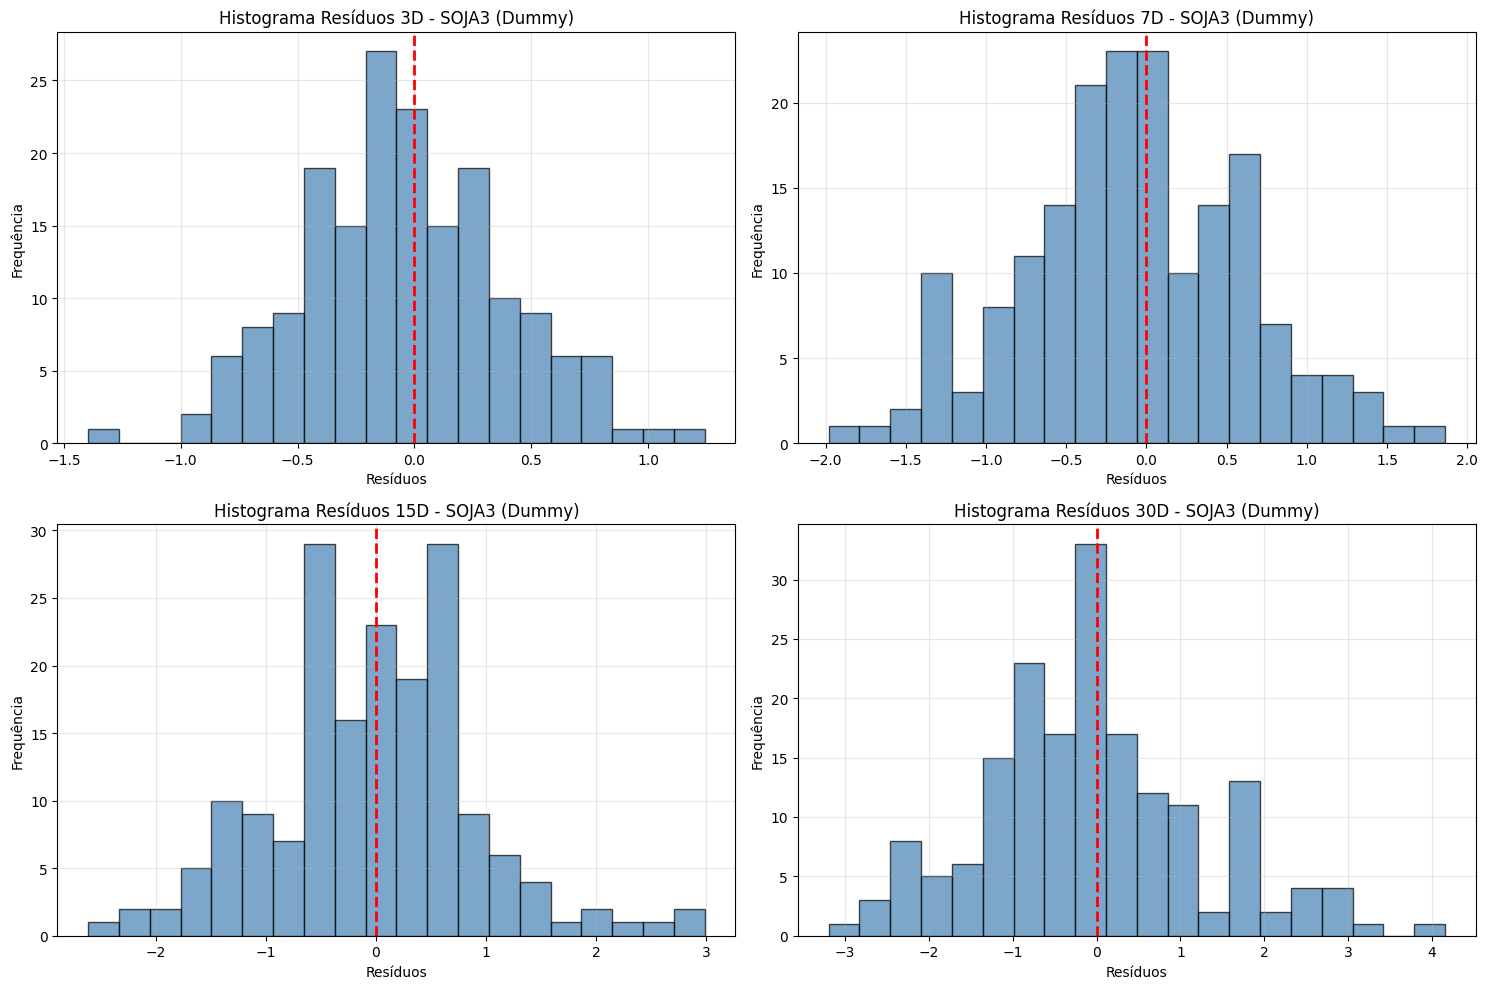

✓ Histograma de resíduos salvo


In [9]:
# Histogramas dos resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Resíduos {period.upper()} - SOJA3 (Dummy)')
    ax.set_xlabel('Resíduos')
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}histograma_residuos_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Histograma de resíduos salvo")

### Resíduos vs Ordem Temporal

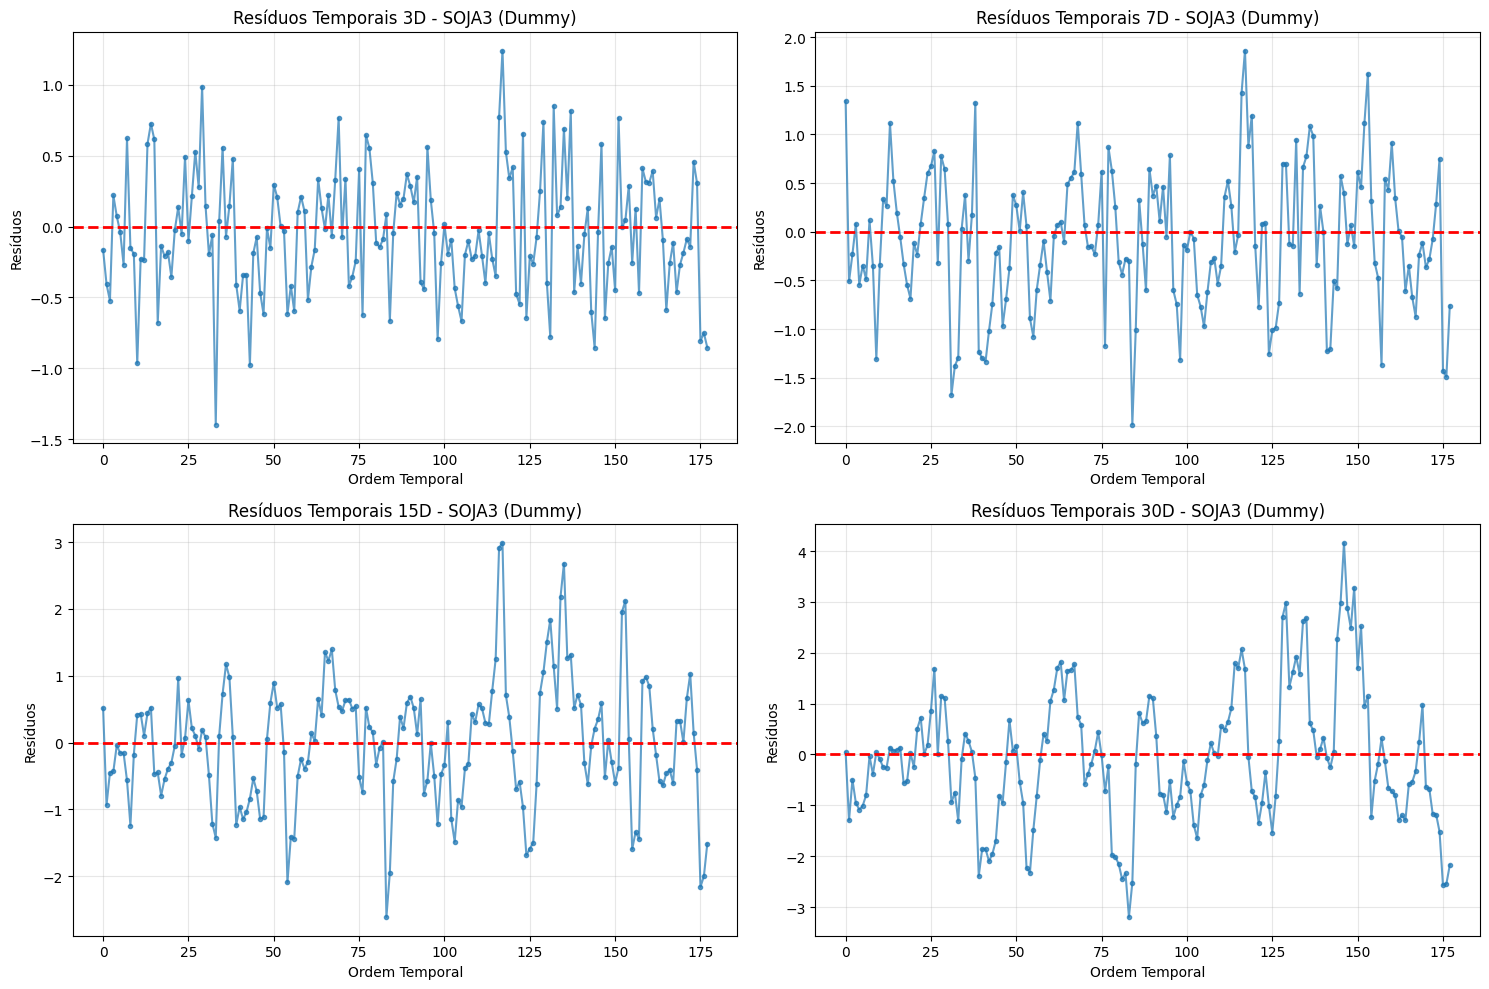

✓ Gráfico de resíduos temporais salvo


In [10]:
# Resíduos vs Ordem Temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Ordenar por índice temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos Temporais {period.upper()} - SOJA3 (Dummy)')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Resíduos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_temporais_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de resíduos temporais salvo")

### Gráfico de Dispersão com Intervalo de Confiança (IC 95%)

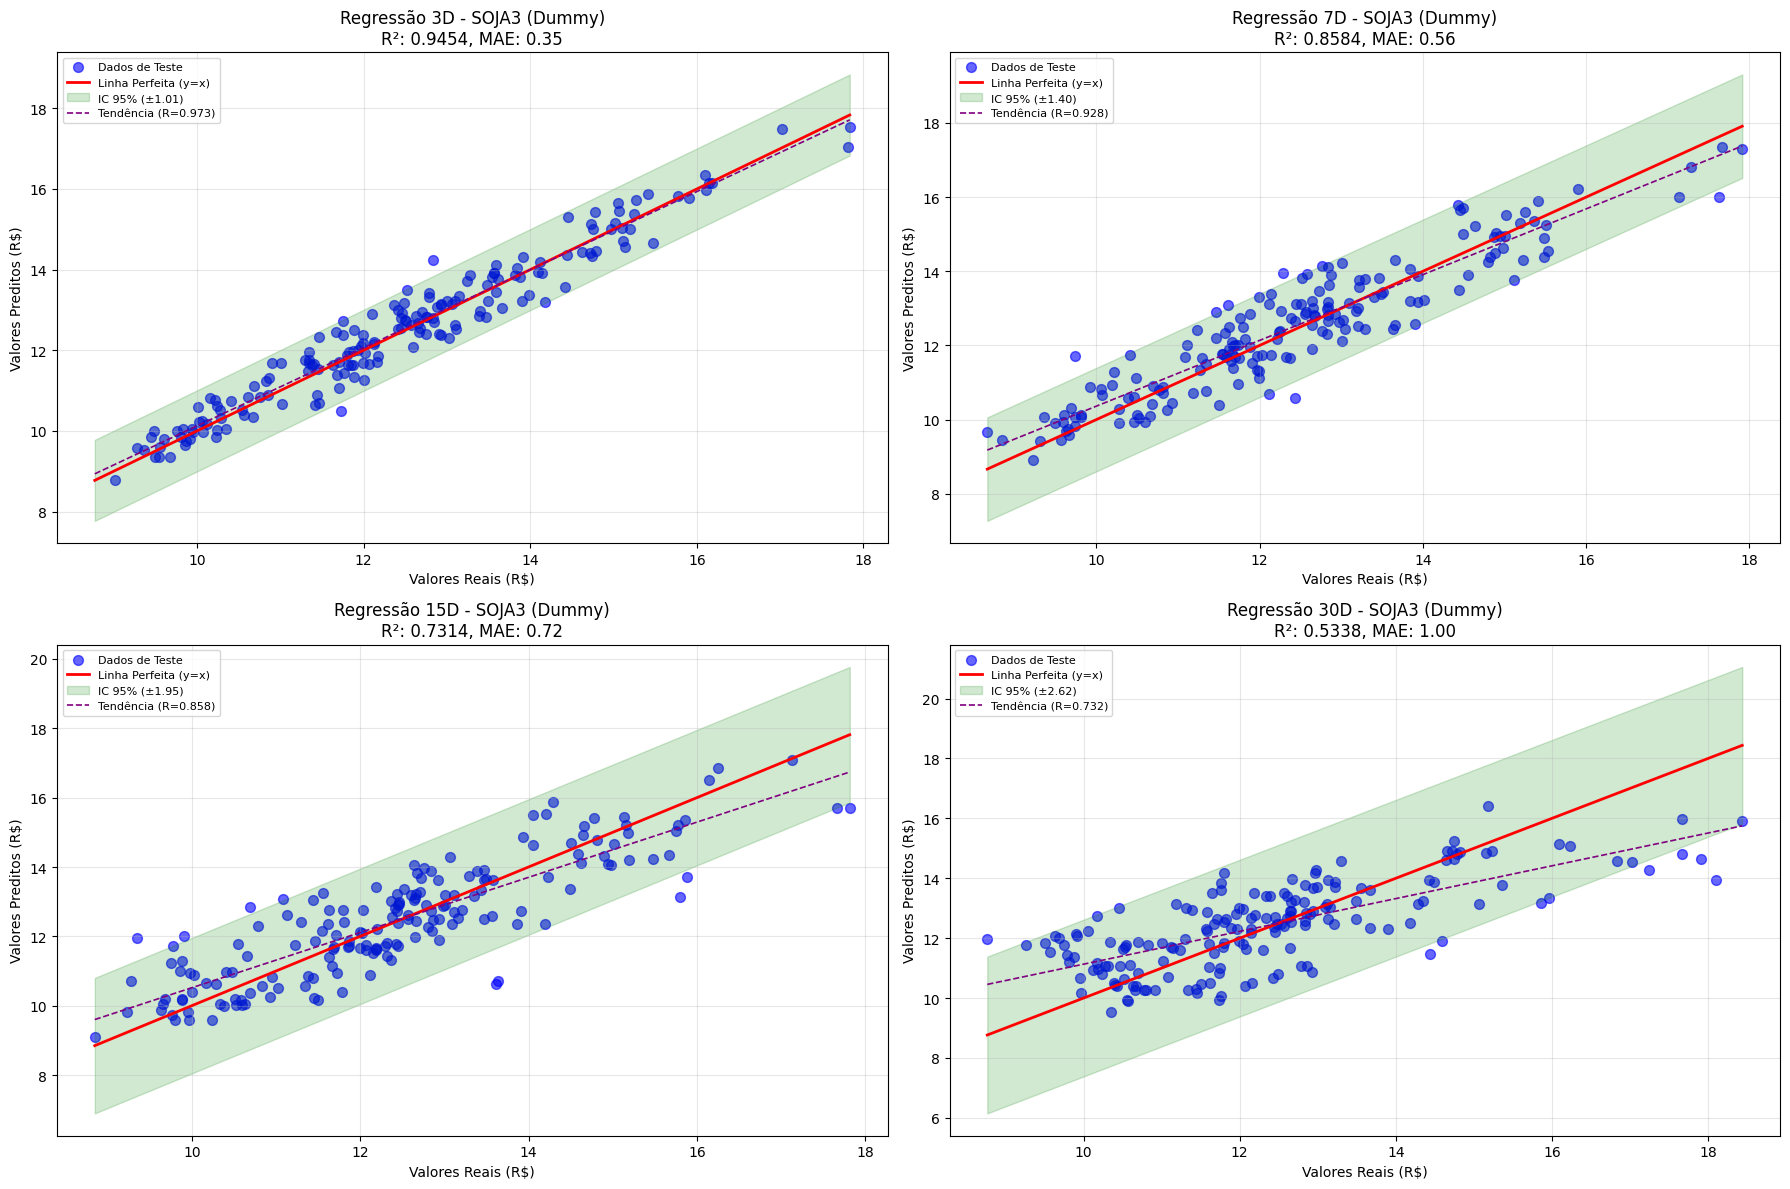

✓ Gráfico de dispersão com IC 95% salvo


In [11]:
# Gráficos de dispersão com linha de regressão e IC 95%
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    y_train = model_data['y_train']
    y_pred_train = model_data['model'].predict(model_data['X_train'])
    
    # Calcular MSE e desvio padrão dos resíduos
    mse = mean_squared_error(y_train, y_pred_train)
    residual_std = np.sqrt(mse)

    ax = axes[idx]

    # Scatter dos dados de teste
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50, label='Dados de Teste')

    # Linha y = x
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')

    # Intervalo de confiança 95%
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals,
                    line_vals - confidence_interval,
                    line_vals + confidence_interval,
                    alpha=0.18, color='green',
                    label=f'IC 95% (±{confidence_interval:.2f})')

    # Linha de tendência
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.2, label=f'Tendência (R={r_value:.3f})')

    ax.set_title(f'Regressão {period.upper()} - SOJA3 (Dummy)\nR²: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}dispersao_ic_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de dispersão com IC 95% salvo")

### Evolução do R² e MAE por Horizonte

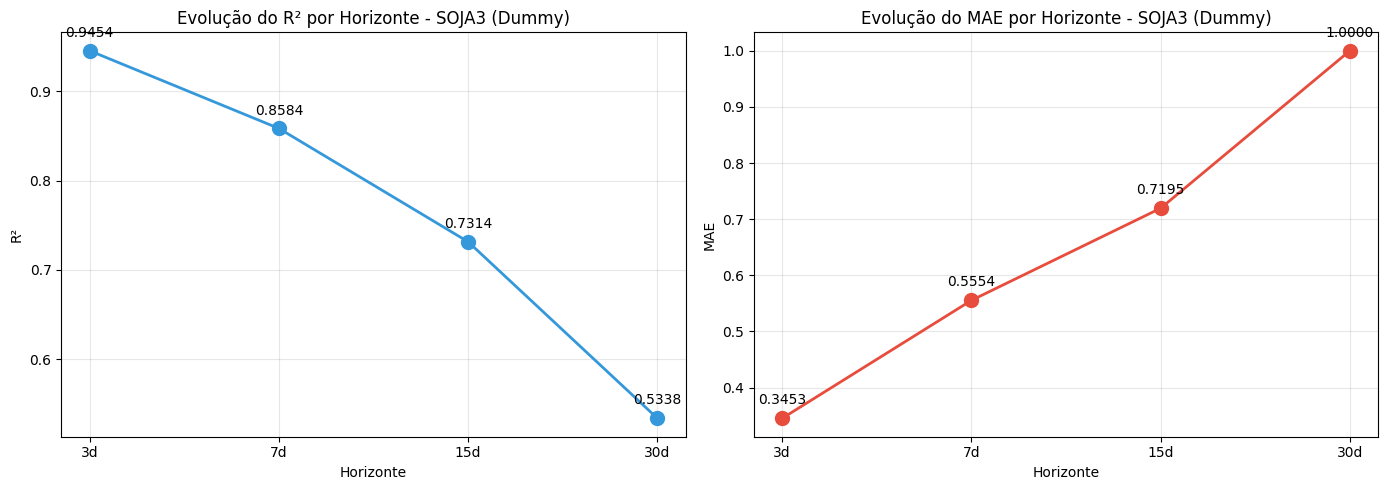

✓ Gráficos de evolução de R² e MAE salvos


In [12]:
# Evolução das métricas R² e MAE por horizonte
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R²
axes[0].plot(periods, r2_values, marker='o', linewidth=2, markersize=10, color='#3498db')
axes[0].set_title('Evolução do R² por Horizonte - SOJA3 (Dummy)')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('R²')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    axes[0].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

# Plot MAE
axes[1].plot(periods, mae_values, marker='o', linewidth=2, markersize=10, color='#e74c3c')
axes[1].set_title('Evolução do MAE por Horizonte - SOJA3 (Dummy)')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_soja3_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráficos de evolução de R² e MAE salvos')

### Resumo Final

In [13]:
print("\n" + "="*60)
print("RESUMO FINAL - REGRESSÃO LINEAR SOJA3 (DATASET DUMMY)")
print("="*60)
print("\n✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)")
print(f"✓ Features utilizadas: {base_features + dummy_cols}")
print("\nMétricas por horizonte:")
for period in ['3d', '7d', '15d', '30d']:
    print(f"  {period}: R²={models[period]['r2']:.4f}, MAE={models[period]['mae']:.4f}, RMSE={models[period]['rmse']:.4f}")

print("\nArquivos gerados:")
print("  - metricas_soja3_dummy.csv")
print("  - serie_temporal_soja3_dummy.png")
print("  - residuos_soja3_dummy.png")
print("  - real_vs_predito_soja3_dummy.png")
print("  - comparacao_metricas_soja3_dummy.png")
print("  - histograma_residuos_soja3_dummy.png")
print("  - residuos_temporais_soja3_dummy.png")
print("  - dispersao_ic_soja3_dummy.png")
print("  - evolucao_metricas_soja3_dummy.png")
print("="*60)


RESUMO FINAL - REGRESSÃO LINEAR SOJA3 (DATASET DUMMY)

✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
✓ Features utilizadas: ['Close', 'Low', 'High', 'Open', 'period_1', 'period_2']

Métricas por horizonte:
  3d: R²=0.9454, MAE=0.3453, RMSE=0.4328
  7d: R²=0.8584, MAE=0.5554, RMSE=0.7010
  15d: R²=0.7314, MAE=0.7195, RMSE=0.9313
  30d: R²=0.5338, MAE=1.0000, RMSE=1.3035

Arquivos gerados:
  - metricas_soja3_dummy.csv
  - serie_temporal_soja3_dummy.png
  - residuos_soja3_dummy.png
  - real_vs_predito_soja3_dummy.png
  - comparacao_metricas_soja3_dummy.png
  - histograma_residuos_soja3_dummy.png
  - residuos_temporais_soja3_dummy.png
  - dispersao_ic_soja3_dummy.png
  - evolucao_metricas_soja3_dummy.png
